# Trustworthy Backtest Framework — Significance & Walk-Forward
## 信じられるバックテストの三本柱（後半二本）

**EN.** A believable backtest must survive three distinct lies. This notebook covers the second and third:

1. **Look-ahead bias** — handled structurally in the engine (`assert_causal`); recapped briefly below.
2. **Could it be luck?** — a *permutation test* and a *bootstrap* confidence interval (`src/backtest/significance.py`).
3. **Did we over-fit?** — *walk-forward analysis* separating in-sample fit from out-of-sample reality (`src/backtest/walkforward.py`).

**JA.** 信じられるバックテストは三つの異なる「嘘」を乗り越える必要があります。本ノートブックはそのうち二本目と三本目を扱います：

1. **ルックアヘッド・バイアス** — エンジン側で構造的に排除（`assert_causal`）。下記で簡単に再確認します。
2. **偶然ではないか？** — *並べ替え検定*と*ブートストラップ*信頼区間。
3. **過剰最適化していないか？** — *ウォークフォワード分析*で、インサンプルの当てはまりとアウトオブサンプルの現実を分離します。

> The strategy (a 50/200 MA cross) is deliberately ordinary. The point is the verification around it, and that we report whatever it says — even an unflattering verdict.
> 戦略（50/200 移動平均クロス）はあえて平凡です。主役はその周囲の検証であり、結果が芳しくなくても正直に報告します。

In [1]:
import sys, pathlib
# Make the repository root importable when running from notebooks/.
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.backtest.engine import run_backtest, BacktestConfig, assert_causal
from src.backtest.strategies import MovingAverageCrossStrategy
from src.backtest import metrics
from src.backtest.data import load_prices
from src.backtest.significance import (
    permutation_test,
    bootstrap_statistic,
    best_strategy_permutation_test,
    bonferroni_adjust,
)
from src.backtest.walkforward import run_walkforward

# One seed governs every Monte-Carlo result below, so the whole notebook
# is reproducible end to end.
SEED = 0

## 1. Data & the strategy under test / データと検証対象の戦略

**EN.** We fetch split/dividend-adjusted SPY closes, falling back to a *clearly labelled* synthetic random walk if offline so the notebook always runs. A driftless random walk has **no edge to find** — a useful honesty check: on it, every test below *should* report no significance.

**JA.** 分割・配当調整済みの SPY 終値を取得し、オフライン時は*明示ラベル付き*の合成ランダムウォークにフォールバックします。ドリフトの無いランダムウォークには**見つけるべき優位性が存在しません**——以下の検定が「有意でない」と正しく報告するかの誠実性チェックになります。

In [2]:
TICKER = "SPY"
START, END = "2010-01-01", "2023-12-31"

try:
    prices = load_prices(TICKER, START, END)
    DATA_SOURCE = f'real ({TICKER}, yfinance)'
except Exception as exc:  # offline / rate-limited -> synthetic fallback
    print(f'Live download failed ({exc!r}); using SYNTHETIC fallback.')
    rng = np.random.default_rng(SEED)
    idx = pd.date_range(START, END, freq='B')
    # Driftless random walk: deliberately edge-free.
    daily = rng.normal(0.0, 0.011, len(idx))
    prices = pd.Series(100 * np.exp(np.cumsum(daily)), index=idx, name=TICKER)
    DATA_SOURCE = 'SYNTHETIC random walk (offline fallback — no real edge)'

print('Data source:', DATA_SOURCE)
print('Observations:', len(prices))

strategy = MovingAverageCrossStrategy(fast_window=50, slow_window=200)
RISK_FREE = 0.02

Data source: real (SPY, yfinance)
Observations: 3522


## 2. Pillar 1 recap — prove no look-ahead / 第一の柱（再確認）

**EN.** Before any significance test means anything, the strategy must be causal on this data. If `assert_causal` raises, stop — nothing below is trustworthy.

**JA.** 有意性検定に意味を持たせる前に、戦略がこのデータ上で因果的である必要があります。`assert_causal` が例外を出したら、以降の結果は信用できません。

In [3]:
assert_causal(strategy, prices, n_trials=10, seed=SEED)
print(f'{strategy.name}: causality check PASSED — no look-ahead bias.')

config = BacktestConfig(commission=0.0005, slippage=0.0005)
result = run_backtest(prices, strategy, config)

# The permutation test works on the *held* position (already execution-
# lagged by the engine) versus the per-bar asset return it was exposed to.
bar_returns = prices.pct_change().fillna(0.0)

print('Strategy Sharpe:', round(metrics.sharpe_ratio(result.returns, RISK_FREE), 3))

MA(50,200): causality check PASSED — no look-ahead bias.
Strategy Sharpe: 0.173


## 3. Pillar 2a — Permutation test / 並べ替え検定

**EN.** Null hypothesis: the strategy's positions carry no information about the contemporaneous return. We simulate that null by shuffling the positions against the (in-order) returns thousands of times and rebuilding the Sharpe each time. The **p-value** is how often luck matches or beats the real Sharpe. The histogram shows the null distribution; the red line is the strategy's actual score.

**JA.** 帰無仮説：戦略のポジションは同時点リターンについて何の情報も持たない。ポジションを（順序そのままの）リターンに対して数千回シャッフルし、その都度シャープを再計算してこの帰無仮説を再現します。**p値**は「偶然が実際のシャープ以上を出す頻度」です。ヒストグラムが帰無分布、赤線が戦略の実スコアです。

In [4]:
perm = permutation_test(
    result.positions, bar_returns, n_permutations=3000, seed=SEED
)
# The permutation tests *timing skill*: position x return, before costs and
# before the risk-free adjustment, so this Sharpe differs slightly from the
# net, rf-adjusted headline number above.
print(f'Observed Sharpe (gross): {perm.observed:.3f}')
print(f'Permutation p-value    : {perm.p_value:.4f}')
verdict = 'SIGNIFICANT' if perm.p_value < 0.05 else 'NOT significant'
print(f'At the 5% level        : {verdict}')

Observed Sharpe (gross): 0.304
Permutation p-value    : 0.8204
At the 5% level        : NOT significant


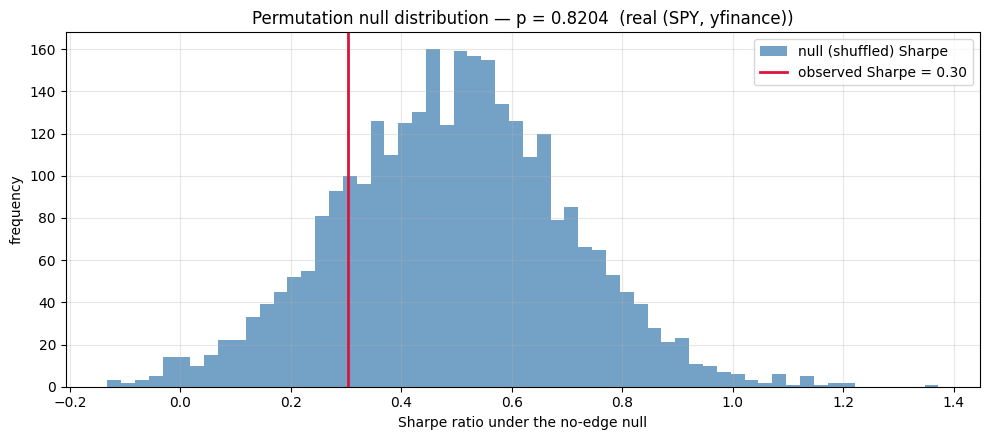

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(perm.null_distribution, bins=60, color='steelblue', alpha=0.75,
        label='null (shuffled) Sharpe')
ax.axvline(perm.observed, color='crimson', lw=2,
           label=f'observed Sharpe = {perm.observed:.2f}')
ax.set_title(f'Permutation null distribution — p = {perm.p_value:.4f}  ({DATA_SOURCE})')
ax.set_xlabel('Sharpe ratio under the no-edge null')
ax.set_ylabel('frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Pillar 2b — Bootstrap confidence interval / ブートストラップ信頼区間

**EN.** A single Sharpe number hides its own uncertainty. We resample the realised returns with replacement and rebuild the Sharpe to get a 95% confidence interval. **If that interval straddles zero, we cannot even claim the Sharpe is positive.** The shaded band marks the interval; the dashed line marks zero.

**JA.** 単一のシャープ値はその不確実性を隠します。実現リターンを復元抽出でリサンプリングしてシャープを再構築し、95% 信頼区間を得ます。**区間が 0 をまたぐなら、シャープが正であるとすら主張できません。** 影の帯が信頼区間、破線が 0 です。

In [6]:
boot = bootstrap_statistic(
    result.returns,
    statistic=lambda r: metrics.sharpe_ratio(r, RISK_FREE),
    n_resamples=3000,
    confidence_level=0.95,
    seed=SEED,
)
print(f'Point Sharpe           : {boot.point_estimate:.3f}')
print(f'95% CI                 : [{boot.lower:.3f}, {boot.upper:.3f}]')
print(f'Standard error         : {boot.standard_error:.3f}')
straddles = boot.lower <= 0.0 <= boot.upper
print('CI straddles zero      :', straddles,
      '(cannot claim a positive Sharpe)' if straddles else '(Sharpe sign is robust)')

Point Sharpe           : 0.173
95% CI                 : [-0.351, 0.687]
Standard error         : 0.263
CI straddles zero      : True (cannot claim a positive Sharpe)


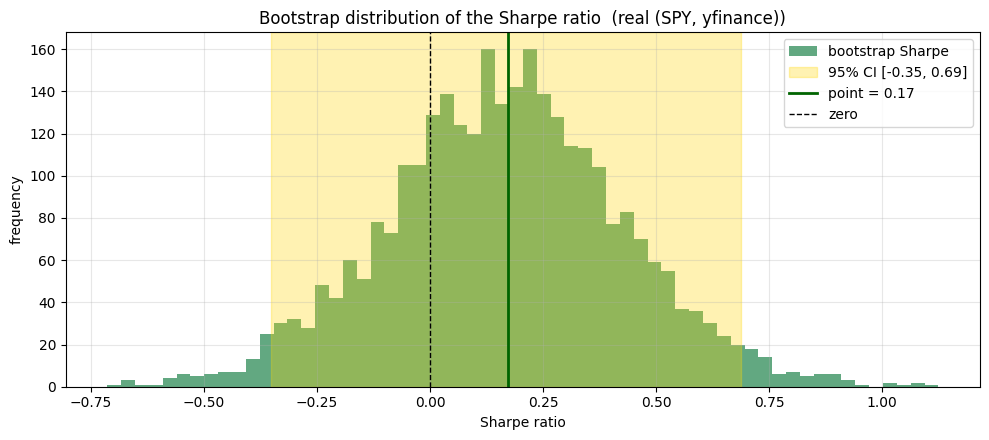

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(boot.distribution, bins=60, color='seagreen', alpha=0.75,
        label='bootstrap Sharpe')
ax.axvspan(boot.lower, boot.upper, color='gold', alpha=0.3,
           label=f'95% CI [{boot.lower:.2f}, {boot.upper:.2f}]')
ax.axvline(boot.point_estimate, color='darkgreen', lw=2,
           label=f'point = {boot.point_estimate:.2f}')
ax.axvline(0.0, color='black', ls='--', lw=1, label='zero')
ax.set_title(f'Bootstrap distribution of the Sharpe ratio  ({DATA_SOURCE})')
ax.set_xlabel('Sharpe ratio')
ax.set_ylabel('frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Pillar 2c — Data snooping / 多重検定（データスヌーピング）

**EN.** The deadliest self-deception: trying many parameter sets and reporting the best. The *best of N* looks good even when none has edge. Two corrections: a crude **Bonferroni** scaling of the single-strategy p-value, and a permutation **Reality Check** whose null is the *maximum* Sharpe across all candidates under the same shuffle — so the cherry-picking is already baked into the null.

**JA.** 最も危険な自己欺瞞は、多数のパラメータを試して最良だけを報告することです。*N 個中の最良*は、どれも優位でなくても良く見えます。二つの補正：単一戦略p値を粗く割り増す**ボンフェローニ**と、同一シャッフル下での全候補の*最大*シャープを帰無分布とする並べ替え版**リアリティ・チェック**——後者はチェリーピッキングを最初から帰無分布に織り込みます。

In [8]:
# A small grid of MA settings — exactly the kind of search that invites
# data snooping.
grid = [
    MovingAverageCrossStrategy(fast, slow)
    for fast in (10, 20, 50)
    for slow in (100, 150, 200)
    if fast < slow
]
positions_list = [run_backtest(prices, s, config).positions for s in grid]

rc = best_strategy_permutation_test(
    positions_list, bar_returns, n_permutations=3000, seed=SEED
)
best = grid[rc.best_index]
print(f'Candidates tried       : {rc.n_candidates}')
print(f'Best candidate         : {best.name}  (Sharpe {rc.observed_best:.3f})')
print(f'Reality-Check p-value  : {rc.p_value:.4f}  (multiplicity-corrected)')
print(f'Naive Bonferroni bound : {bonferroni_adjust(perm.p_value, len(grid)):.4f}')

Candidates tried       : 9
Best candidate         : MA(50,150)  (Sharpe 0.388)
Reality-Check p-value  : 0.9047  (multiplicity-corrected)
Naive Bonferroni bound : 1.0000


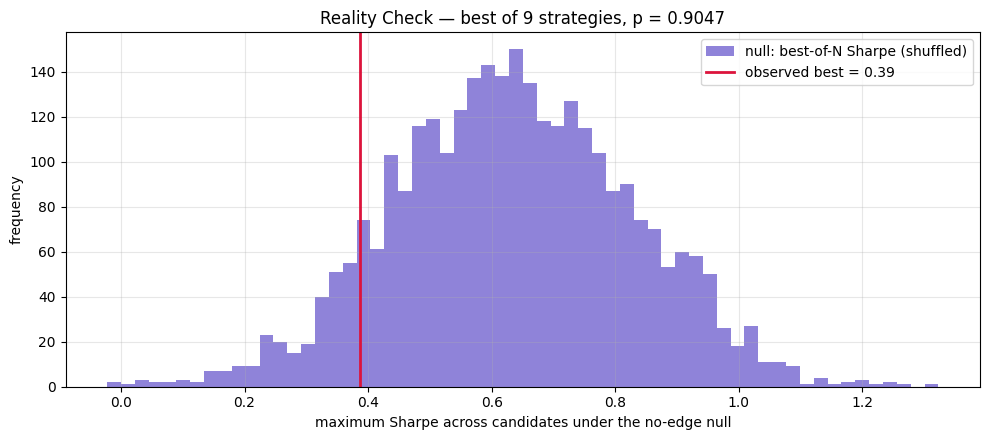

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(rc.null_distribution, bins=60, color='slateblue', alpha=0.75,
        label='null: best-of-N Sharpe (shuffled)')
ax.axvline(rc.observed_best, color='crimson', lw=2,
           label=f'observed best = {rc.observed_best:.2f}')
ax.set_title(f'Reality Check — best of {rc.n_candidates} strategies, p = {rc.p_value:.4f}')
ax.set_xlabel('maximum Sharpe across candidates under the no-edge null')
ax.set_ylabel('frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Pillar 3 — Walk-forward analysis / ウォークフォワード分析

**EN.** Each fold selects the best MA setting on an **in-sample** window, then scores that choice on the **out-of-sample** window immediately after it — data the selection never saw. The gap between the two, the **degradation**, is the over-fitting made visible. We use the anchored (expanding) scheme.

**JA.** 各フォールドで**インサンプル**窓の最良 MA を選び、その選択を直後の**アウトオブサンプル**窓で評価します——選択時に見ていないデータです。両者の差（**劣化, degradation**）が過剰最適化を可視化します。アンカード（拡大窓）方式を用います。

In [10]:
wf = run_walkforward(
    prices,
    grid,
    train_size=500,   # ~2 trading years in-sample
    test_size=125,    # ~0.5 trading year out-of-sample
    mode='anchored',
    config=config,
)

rows = [
    {
        'in_sample_end': w.train_end_date.date(),
        'oos_end': w.test_end_date.date(),
        'chosen': w.best_strategy_name,
        'IS Sharpe': round(w.in_sample_score, 3),
        'OOS Sharpe': round(w.out_of_sample_score, 3),
    }
    for w in wf.windows
]
table = pd.DataFrame(rows)
print(f'Folds                  : {len(wf.windows)}')
print(f'Mean IS Sharpe         : {wf.mean_in_sample:.3f}')
print(f'Mean OOS Sharpe        : {wf.mean_out_of_sample:.3f}')
print(f'Degradation (IS - OOS) : {wf.degradation:.3f}')
print(f'Walk-forward efficiency: {wf.efficiency:.2f}  (OOS / IS)')
table

Folds                  : 24
Mean IS Sharpe         : 0.417
Mean OOS Sharpe        : 0.680
Degradation (IS - OOS) : -0.263
Walk-forward efficiency: 1.63  (OOS / IS)


,in_sample_end,oos_end,chosen,IS Sharpe,OOS Sharpe
0,2011-12-23,2012-06-25,"MA(50,100)",0.327,0.606
1,2012-06-25,2012-12-24,"MA(50,100)",0.366,-0.637
2,2012-12-24,2013-06-25,"MA(50,100)",0.243,0.343
3,2013-06-25,2013-12-20,"MA(10,200)",0.386,3.022
4,2013-12-20,2014-06-23,"MA(10,200)",0.607,1.682
5,2014-06-23,2014-12-18,"MA(10,200)",0.694,1.053
6,2014-12-18,2015-06-19,"MA(10,200)",0.724,0.644
7,2015-06-19,2015-12-16,"MA(10,200)",0.717,-2.469
8,2015-12-16,2016-06-16,"MA(50,150)",0.506,-2.638
9,2016-06-16,2016-12-13,"MA(50,150)",0.256,1.792


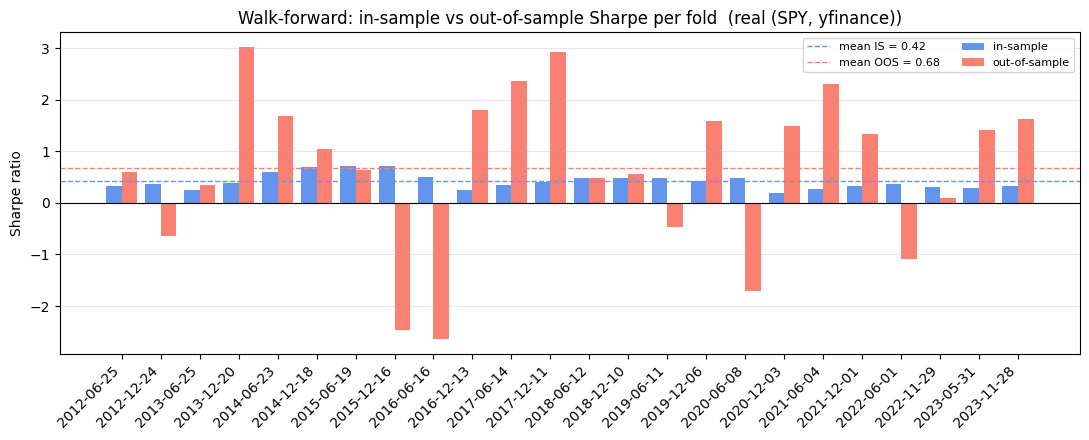

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(wf.windows))
labels = [w.test_end_date.date() for w in wf.windows]
ax.bar(x - 0.2, wf.in_sample_scores, width=0.4, label='in-sample', color='cornflowerblue')
ax.bar(x + 0.2, wf.out_of_sample_scores, width=0.4, label='out-of-sample', color='salmon')
ax.axhline(wf.mean_in_sample, color='cornflowerblue', ls='--', lw=1,
           label=f'mean IS = {wf.mean_in_sample:.2f}')
ax.axhline(wf.mean_out_of_sample, color='salmon', ls='--', lw=1,
           label=f'mean OOS = {wf.mean_out_of_sample:.2f}')
ax.axhline(0.0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title(f'Walk-forward: in-sample vs out-of-sample Sharpe per fold  ({DATA_SOURCE})')
ax.set_ylabel('Sharpe ratio')
ax.legend(ncol=2, fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Honest verdict / 正直な結論

**EN.** Read the numbers, not your hopes — and read the *next cell*, which states the verdict from whatever the data actually produced (it is not hard-coded, so it stays honest as the data updates). The methodological point is fixed even when the numbers move:

- **Permutation test** answers *could this edge be luck?* A high p-value means luck reproduces it easily.
- **Bootstrap interval** answers *how precise is the Sharpe?* An interval straddling zero means we cannot even sign it.
- **Reality Check** answers *did searching many settings fool us?* It corrects the best-of-N for the search itself.
- **Walk-forward degradation** answers *did we over-fit?* Positive degradation (IS > OOS) is the over-fitting signature; near-zero or negative degradation means the in-sample fit did **not** inflate — but note this alone does *not* establish an edge: a strategy can avoid over-fitting and still be statistically indistinguishable from zero.

A strategy is only believable when it clears **all** of these at once. *On the synthetic random-walk fallback there is no edge by construction, so honest tests must fail to find one.*

**JA.** 期待ではなく数値を、そして**次のセル**を読んでください。次のセルは実際のデータが出した結果から結論を述べます（ハードコードしていないので、データが更新されても誠実なままです）。数値が動いても手法上の要点は不変です：

- **並べ替え検定**＝*この優位性は偶然か？* p値が高ければ偶然で容易に再現できる。
- **ブートストラップ区間**＝*シャープはどれだけ精確か？* 区間が 0 をまたげば符号すら確定できない。
- **リアリティ・チェック**＝*多数の設定を試して自分を欺いたか？* 探索そのものを補正する。
- **ウォークフォワードの劣化**＝*過剰最適化したか？* 正の劣化（IS > OOS）が過剰最適化の兆候。0 近傍や負なら当てはめは過大評価していない——ただしそれだけでは優位性の証明にはならない（過剰最適化を免れても 0 と区別できないことはある）。

戦略が信じられるのは、これら**すべて**を同時にクリアしたときだけです。*合成ランダムウォークでは構造上優位性が無く、誠実な検定はそれを見つけられないはずです。*

> The deliverable is the verification, not a winning strategy. A framework that can tell you 'this is probably nothing' is worth far more than one that always flatters you.
> 成果物は勝てる戦略ではなく検証そのものです。『これはおそらく無価値だ』と言えるフレームワークは、常に甘く評価するものよりはるかに価値があります。

In [12]:
# A data-driven verdict: assembled from the actual results above, so it
# can never drift out of sync with the numbers.
checks = {
    'permutation finds a real edge (p < 0.05)': perm.p_value < 0.05,
    'bootstrap Sharpe is robustly positive (CI > 0)': boot.lower > 0.0,
    'best-of-N survives data snooping (p < 0.05)': rc.p_value < 0.05,
    'no over-fitting (degradation <= 0)': wf.degradation <= 0.0,
}
for label, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}]  {label}")

believable = checks['permutation finds a real edge (p < 0.05)'] and \
    checks['bootstrap Sharpe is robustly positive (CI > 0)'] and \
    checks['best-of-N survives data snooping (p < 0.05)']
print()
print('VERDICT:', 'a believable, statistically supported edge.'
      if believable else
      'NOT a believable edge — consistent with luck. Reported honestly.')

[FAIL]  permutation finds a real edge (p < 0.05)
[FAIL]  bootstrap Sharpe is robustly positive (CI > 0)
[FAIL]  best-of-N survives data snooping (p < 0.05)
[PASS]  no over-fitting (degradation <= 0)

VERDICT: NOT a believable edge — consistent with luck. Reported honestly.
